This notebook is here as a last minute thing after the error with the jupiter notebook in visual studio that stoped working

For this I need the:
validation set /beta
the ridge regression model
the featue weigths (just in case), please make sure they are in colab folder

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import pickle

In [4]:

import catboost

In [13]:
shap_catboost_df= pd.read_csv("shap_values_by_gene_Catboost_40_extended.csv")
shap_ridge_df = pd.read_csv("shap_values_by_gene_Ridge_40_extended.csv")


In [9]:
# remove columns with 0 values
shap_catboost_df = shap_catboost_df.loc[:, (shap_catboost_df != 0).any(axis=0)]
shap_catboost_df

,CFTR,RECQL,HSPB6,SKAP2,GGCT,BLTP2,FAM76A,TFB1M,DAPK2,ZZZ3,...,ENSG00000259646.1,ENSG00000260212.1,ENSG00000260914.3,ENSG00000262855.1,ENSG00000267771.1,URGCP-MRPS24,ENSG00000270835.2,NUDT4P2,ENSG00000271250.1,ENSG00000271900.1
0,-0.004830,0.000000,-0.329816,0.000351,0.009744,0.000270,0.004003,0.000974,-0.098168,-0.000809,...,-0.003357,-0.012054,-0.033900,-2.275329,-0.028262,-0.003059,-0.001130,-0.006345,-0.021563,-0.008976
1,0.002964,0.000000,-0.300962,0.000351,0.008624,0.000270,-0.009970,-0.000084,-0.098168,-0.000809,...,0.001235,-0.012054,-0.034078,-2.227768,-0.052024,-0.003059,-0.001130,-0.006345,-0.021563,-0.007045
2,0.002964,0.000000,-0.305052,0.000351,0.009037,0.000270,0.005260,-0.000084,-0.098168,-0.000809,...,-0.003357,-0.012054,0.011851,-2.441883,-0.051715,-0.003059,-0.001130,0.000836,-0.021563,-0.007045
3,-0.009230,0.000000,-0.342927,0.000351,0.017175,0.002847,-0.023137,-0.000084,-0.098168,0.003834,...,-0.005405,-0.000128,0.011851,-2.379598,-0.061891,-0.001443,-0.001130,0.000836,-0.018399,-0.000129
4,0.005368,0.000000,0.117744,0.001013,0.038092,-0.014731,0.015580,-0.030016,0.091668,-0.033944,...,0.004434,0.003310,0.010071,2.120787,-0.023364,-0.001443,0.001232,0.003555,-0.018399,0.004118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,-0.009230,0.000000,0.118324,0.001013,0.036228,0.007782,0.013763,0.005690,0.091668,0.003834,...,0.005821,0.007405,0.012885,2.158750,0.067137,-0.001443,0.001232,0.003555,-0.018399,0.004118
104,0.002964,0.341344,-0.312116,0.000351,0.009696,0.000270,-0.013020,-0.000084,-0.098168,-0.000809,...,-0.003357,-0.012054,0.011889,-2.429263,-0.052024,-0.003059,-0.001130,0.000836,-0.021563,-0.008976
105,-0.009230,0.000000,0.124403,0.000598,0.039807,0.007782,0.013763,0.005690,0.091668,0.003834,...,0.001235,-0.000128,0.013055,2.248219,0.080374,-0.001443,0.000466,0.003555,-0.018399,0.004118
106,-0.009230,0.000000,0.105013,0.001013,0.040529,0.002847,-0.023137,0.005690,0.091668,-0.033944,...,0.005821,-0.006606,0.011681,2.150334,0.080374,-0.001443,0.001232,0.003555,0.023144,0.004118


In [18]:
# for each row in shap_df, get the top 50 genes with the highest absolute shap value
# and save them in a new dataframe
def get_frequent_shap(shap_df, top_n=50):
    top_genes={}
    for index, row in shap_df.iterrows():
        top_50_genes = row.abs().nlargest(top_n)
        # save the origial shapvalue non abs
        genes = top_50_genes.index
        origial_shapvalue = row[genes]
        top_genes[index] = origial_shapvalue.to_dict()
    top_genes_set = {}
    for key, value in top_genes.items():
        top_genes_set[key] = set(value.keys())
    # find intersection of top genes_set
    intersection = top_genes_set[0]
    for key, value in top_genes_set.items():
        intersection = intersection.intersection(value)
    return intersection, top_genes_set

In [ ]:
intersection_catboost, top_genes_catboost = get_frequent_shap(shap_catboost_df, top_n=5)


In [38]:
intersection_ridge, top_genes_ridge = get_frequent_shap(shap_ridge_df, top_n=250)
len(intersection_ridge)

22

In [37]:
intersection_ridge

{'ENSG00000269028.3', 'MYL2'}

In [30]:
top_genes_ridge[100]

{'ENO3',
 'ENSG00000225840.2',
 'ENSG00000269028.3',
 'MT-CO1',
 'MT-CO2',
 'MT-ND3',
 'MYBPC1',
 'MYL2',
 'TNNC1',
 'TPM3'}

In [24]:
shap_ridge_df.head()

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,...,C4orf36.1,TUSC2P1,ENSG00000285471.1,OR4M2-OT1,ENSG00000285476.1,H2BK1,OR1Q1BP,ENSG00000285505.1,ENSG00000285508.1,TBCEL-TECTA
0,0.000085,0.000107,-0.000237,-0.000007,0.000003,0.000201,0.000005,0.000017,0.000288,0.000007,...,-0.000052,0.000128,0.000104,0.000126,9.911799e-05,0.000078,0.000134,0.000125,-6.502319e-06,0.000128
1,-0.000047,0.000057,-0.000236,0.000088,0.000005,0.000110,-0.000006,-0.000133,-0.000129,-0.000021,...,-0.000140,0.000079,0.000071,0.000079,6.956985e-05,0.000039,0.000084,0.000078,-5.186453e-07,0.000085
2,-0.000613,-0.000205,-0.000237,-0.000083,-0.000004,-0.000203,0.000013,0.000104,0.000071,0.000011,...,0.000064,-0.000210,-0.000176,-0.000207,-1.667267e-04,-0.000116,-0.000212,-0.000204,-8.005405e-06,-0.000226
3,-0.000214,-0.000138,0.000082,-0.000140,-0.000010,-0.000086,0.000011,0.000333,0.000036,0.000039,...,0.000268,-0.000133,-0.000134,-0.000134,-1.082995e-04,-0.000034,-0.000139,-0.000131,1.446818e-05,-0.000162
4,0.000132,-0.000016,0.000559,0.000064,0.000002,-0.000011,-0.000067,-0.000230,-0.000512,-0.000031,...,-0.000105,-0.000011,-0.000013,-0.000011,-6.815634e-07,-0.000042,-0.000009,-0.000011,4.367867e-06,-0.000014


In [ ]:
# get average shap_df by column
shap_df_mean = shap_catboost_df.mean().sort_values(ascending=False)

# remove the shap_df_mean values that are between -0.001 and 0.001
len(shap_df_mean[(shap_df_mean < -0.001) | (shap_df_mean > 0.001)])


51

In [ ]:
shap_ridge_df_mean.to_csv("average_shap_value_by_gene_Ridge_40_extended.csv")

In [10]:
shap_catboost_df['MYL2']

KeyError: 'MYL2'

In [47]:
results.head(10)

,Actual,Predicted,Group
0,24.0,23.221191,GSE157585
1,18.0,26.198732,GSE167186
2,23.0,24.289711,GSE167186
3,26.4,43.500786,GSE60590
4,71.0,68.304524,GSE157585
5,26.4,34.590884,GSE60590
6,71.0,69.392695,GSE157585
7,27.5,30.070739,GSE60590
8,31.0,30.595556,GSE164471
9,92.0,76.261705,GSE167186


In [ ]:
# @title Group vs Difference

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results['Group'].unique()))
plt.figure(figsize=figsize)
results['Difference'] = abs(results['Predicted'] - results['Actual'])
sns.violinplot(results, x='Difference', y='Group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# @title Group

from matplotlib import pyplot as plt
import seaborn as sns
results.groupby('Group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# prompt: Using dataframe results: calculate per group, what is the average absolute difference between predicted and Actual

# Calculate the absolute difference between predicted and actual values
results['Difference'] = abs(results['Predicted'] - results['Actual'])

# Group by 'Group' and calculate the average absolute difference
average_difference_by_group = results.groupby('Group')['Difference'].mean()

# Display the result
average_difference_by_group


In [ ]:
results[results["Group"]=="GSE152558"]

Sample 6/ 108 
 Age: 71.0 
 Experiment: GSE157585 
 Predicted: Actual            71.0
Predicted    69.392695
Group        GSE157585
Name: 6, dtype: object


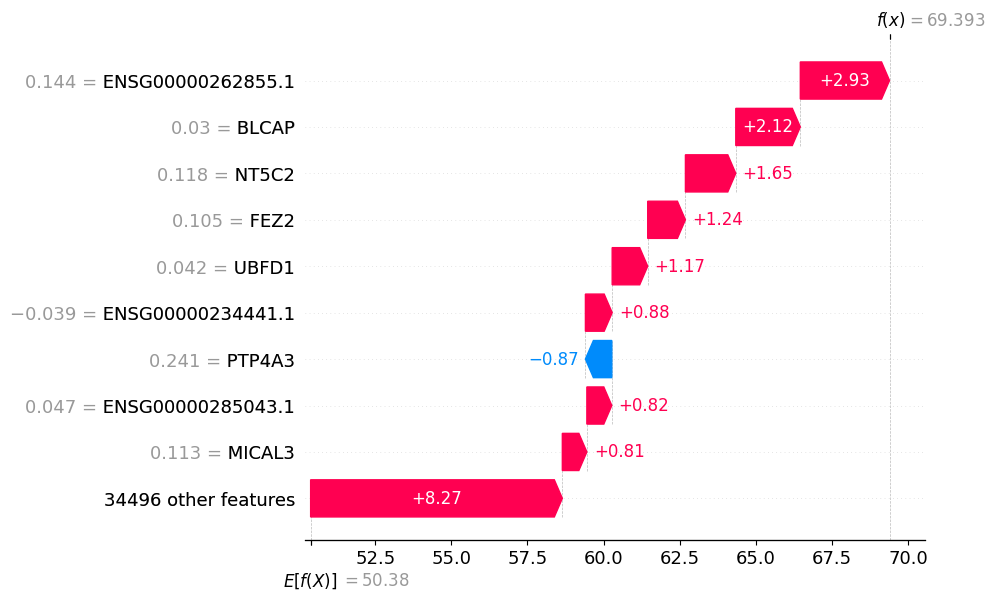

In [97]:
index=6
title = f"Sample {index}/ {len(shap_values)} \n Age: {y_test_data[index]} \n Experiment: {z_test_data[index]} \n Predicted: {results.iloc[index]}"

print(title)
shap.plots.waterfall(shap_values[index])


In [ ]:
# prompt: Run the shap.summary_plot

plot_shap =shap.summary_plot(shap_values, X_test_data, max_display=10)

In [ ]:
# prompt: save the shap figure

import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test_data, max_display=10, show=False)
plt.savefig('summary_plot_catboost.png', bbox_inches='tight')